# Type 2 Diabetes Mellitus Prevalence, Risk Factors, and Trajectory 

### Libraries

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import json
import numpy as np
import geopandas as gpd
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

### Data Import and Cleaning

In [3]:
df_T2D = pd.read_csv("../data/prev_num_allc_2023_both_T2D.csv")
df_population = pd.read_csv("../data/pop_allc_allc_2023.csv")
df_agestand = pd.read_csv("../data/agestand_allc_ally_perc_T2D.csv")

In [22]:
df_T2D.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,5,Prevalence,25,Micronesia (Federated States of),3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.000000,0.000000,0.000000
1,5,Prevalence,25,Micronesia (Federated States of),3,Both,6,5-9 years,976,Diabetes mellitus type 2,1,Number,2023,0.000000,0.000000,0.000000
2,5,Prevalence,25,Micronesia (Federated States of),3,Both,7,10-14 years,976,Diabetes mellitus type 2,1,Number,2023,0.000000,0.000000,0.000000
3,5,Prevalence,25,Micronesia (Federated States of),3,Both,8,15-19 years,976,Diabetes mellitus type 2,1,Number,2023,171.971711,217.670826,137.720850
4,5,Prevalence,25,Micronesia (Federated States of),3,Both,9,20-24 years,976,Diabetes mellitus type 2,1,Number,2023,513.331609,629.248644,408.164848


In [ ]:
df_population[["location_name", "val", "sex_name"]].head()

,location_name,val,sex_name
0,Ukraine,2.858014e+04,Both
1,Global,6.293708e+06,Both
2,Brunei Darussalam,1.062633e+02,Both
3,Japan,4.132141e+06,Both
4,Japan,4.962771e+06,Both


In [4]:
df_agestand.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,5,Prevalence,38,Mongolia,1,Male,27,Age-standardized,976,Diabetes mellitus type 2,2,Percent,1990,0.034660,0.039224,0.031055
1,5,Prevalence,38,Mongolia,2,Female,27,Age-standardized,976,Diabetes mellitus type 2,2,Percent,1990,0.027938,0.031120,0.025278
2,5,Prevalence,38,Mongolia,3,Both,27,Age-standardized,976,Diabetes mellitus type 2,2,Percent,1990,0.031059,0.034615,0.028134
3,5,Prevalence,61,Republic of Moldova,1,Male,27,Age-standardized,976,Diabetes mellitus type 2,2,Percent,1990,0.028187,0.032057,0.024442
4,5,Prevalence,61,Republic of Moldova,2,Female,27,Age-standardized,976,Diabetes mellitus type 2,2,Percent,1990,0.025142,0.028111,0.022238


In [5]:
cols_to_fix = ['val', 'upper', 'lower']
df_agestand[cols_to_fix] = df_agestand[cols_to_fix] * 100

In [ ]:
df_agestand = pd.read_csv("../data/agestand_allc_ally_perc_T2D.csv")
cols_to_fix = ['val', 'upper', 'lower']
df_agestand[cols_to_fix] = df_agestand[cols_to_fix] * 100
with open("../data/regions_updated.json", "r", encoding="utf-8") as f:
    regions = json.load(f)

country_to_region = {
    country: region
    for region, countries in regions.items()
    for country in countries
}

country_to_region["Global"] = "Global"

df_agestand["region"] = [country_to_region[acountry] for acountry in df_agestand["location_name"].to_list()]

In [11]:
df_merged = df_T2D.merge(df_population[["location_name", "val", "sex_name", "age_name"]], on=["location_name", "sex_name", "age_name"], how="left", suffixes=["_T2D", "_population"])

In [12]:
df = pd.concat([df_merged, df_agestand])

In [15]:
df[df["location_name"] == "Lithuania"]

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val_T2D,upper,lower,val_population,val
1500,5,Prevalence,60,Lithuania,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.000000,0.000000,0.000000,123884.520994,NaN
1501,5,Prevalence,60,Lithuania,3,Both,6,5-9 years,976,Diabetes mellitus type 2,1,Number,2023,0.000000,0.000000,0.000000,147293.832962,NaN
1502,5,Prevalence,60,Lithuania,3,Both,7,10-14 years,976,Diabetes mellitus type 2,1,Number,2023,0.000000,0.000000,0.000000,148675.894133,NaN
1503,5,Prevalence,60,Lithuania,3,Both,8,15-19 years,976,Diabetes mellitus type 2,1,Number,2023,267.226907,423.990872,96.942653,133121.570872,NaN
1504,5,Prevalence,60,Lithuania,3,Both,9,20-24 years,976,Diabetes mellitus type 2,1,Number,2023,710.682975,934.260045,505.471858,136811.736154,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20212,5,Prevalence,60,Lithuania,2,Female,27,Age-standardized,976,Diabetes mellitus type 2,2,Percent,2022,NaN,3.803090,3.022556,NaN,3.401900
20213,5,Prevalence,60,Lithuania,3,Both,27,Age-standardized,976,Diabetes mellitus type 2,2,Percent,2022,NaN,4.396721,3.634682,NaN,3.990833
20553,5,Prevalence,60,Lithuania,1,Male,27,Age-standardized,976,Diabetes mellitus type 2,2,Percent,2023,NaN,5.548536,4.406041,NaN,5.018991
20554,5,Prevalence,60,Lithuania,2,Female,27,Age-standardized,976,Diabetes mellitus type 2,2,Percent,2023,NaN,3.992430,3.171451,NaN,3.567588


In [16]:
age_order = [
    "<5 years", "5-9 years", "10-14 years", "15-19 years",
    "20-24 years", "25-29 years", "30-34 years", "35-39 years",
    "40-44 years", "45-49 years", "50-54 years", "55-59 years",
    "60-64 years", "65-69 years", "70-74 years", "75-79 years",
    "80-84 years", "85-89 years", "90-94 years", "95+ years"
]

df["age_name"] = pd.Categorical(df["age_name"], categories=age_order, ordered=True)
df = df.sort_values("age_name")

In [17]:
with open("../data/regions_updated.json", "r", encoding="utf-8") as f:
    regions = json.load(f)
    
country_to_region = {
    country: region
    for region, countries in regions.items()
    for country in countries
}

country_to_region["Global"] = "Global"

df["region"] = [country_to_region[acountry] for acountry in df["location_name"].to_list()]

Weighted average
https://www.datacamp.com/tutorial/weighted-average-formula?dc_referrer=https%3A%2F%2Fwww.google.com%2F

95CI = x̄ ± 1.96 × SE  
(95upper - 95lower) / (1.96 * 2) = SE 
https://online.stat.psu.edu/statprogram/reviews/statistical-concepts/confidence-intervals

In [18]:
df_both = df[(df["sex_name"] == "Both") & (df["metric_name"] == "Number")]

In [19]:
df_both.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val_T2D,upper,lower,val_population,val,region
0,5,Prevalence,25,Micronesia (Federated States of),3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0,9.497376e+03,NaN,Oceania
2459,5,Prevalence,127,El Salvador,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0,4.395040e+05,NaN,Latin America and Caribbean
2480,5,Prevalence,55,Slovenia,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0,9.541188e+04,NaN,Central and Eastern Europe
2496,5,Prevalence,393,Saint Kitts and Nevis,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0,2.979567e+03,NaN,Latin America and Caribbean
2516,5,Prevalence,165,Pakistan,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0,3.082825e+07,NaN,South and Southeast Asia


In [20]:
df_pivot = df_both.pivot(
    index=["location_name", "age_name", "region"],
    values=["val_T2D", "upper", "lower", "val_population"],
    columns=["metric_name"]
)

df_pivot

val_T2D  \
metric_name                                                    Number   
location_name age_name    region                                        
Afghanistan   <5 years    North Africa and Middle East       0.000000   
              5-9 years   North Africa and Middle East       0.000000   
              10-14 years North Africa and Middle East       0.000000   
              15-19 years North Africa and Middle East   41965.506768   
              20-24 years North Africa and Middle East  129213.674520   
...                                                               ...   
Zimbabwe      75-79 years Sub-Saharan Africa             25153.122974   
              80-84 years Sub-Saharan Africa             14562.571912   
              85-89 years Sub-Saharan Africa              6681.318482   
              90-94 years Sub-Saharan Africa              2107.852163   
              95+ years   Sub-Saharan Africa               863.710373   

                                                                upper  \
metric_name                                                    Number   
location_name age_name    region                                        
Afghanistan   <5 years    North Africa and Middle East       0.000000   
              5-9 years   North Africa and Middle East       0.000000   
              10-14 years North Africa and Middle East       0.000000   
              15-19 years North Africa and Middle East   54234.711950   
              20-24 years North Africa and Middle East  159672.889089   
...                                                               ...   
Zimbabwe      75-79 years Sub-Saharan Africa             28223.186412   
              80-84 years Sub-Saharan Africa             16408.325516   
              85-89 years Sub-Saharan Africa              7563.180523   
              90-94 years Sub-Saharan Africa              2471.747110   
              95+ years   Sub-Saharan Africa              1091.666735   

                                                                lower  \
metric_name                                                    Number   
location_name age_name    region                                        
Afghanistan   <5 years    North Africa and Middle East       0.000000   
              5-9 years   North Africa and Middle East       0.000000   
              10-14 years North Africa and Middle East       0.000000   
              15-19 years North Africa and Middle East   31890.081397   
              20-24 years North Africa and Middle East  101537.648079   
...                                                               ...   
Zimbabwe      75-79 years Sub-Saharan Africa             22695.134722   
              80-84 years Sub-Saharan Africa             13098.449432   
              85-89 years Sub-Saharan Africa              5854.262007   
              90-94 years Sub-Saharan Africa              1776.138860   
              95+ years   Sub-Saharan Africa               692.637018   

                                                       val_population  
metric_name                                                    Number  
location_name age_name    region                                       
Afghanistan   <5 years    North Africa and Middle East   6.212734e+06  
              5-9 years   North Africa and Middle East   5.468729e+06  
              10-14 years North Africa and Middle East   4.662162e+06  
              15-19 years North Africa and Middle East   4.040897e+06  
              20-24 years North Africa and Middle East   3.323668e+06  
...                                                               ...  
Zimbabwe      75-79 years Sub-Saharan Africa             1.182523e+05  
              80-84 years Sub-Saharan Africa             7.355388e+04  
              85-89 years Sub-Saharan Africa             4.209960e+04  
              90-94 years Sub-Saharan Africa             1.914952e+04  
              95+ years   Sub-Saharan Africa             

In [21]:
df_pivot["se", "Number"] = (df_pivot["upper", "Number"] - df_pivot["lower", "Number"]) / (1.96 * 2)
df_pivot["var", "Number"] = df_pivot["se", "Number"] ** 2
df_pivot.head()

val_T2D  \
metric_name                                                    Number   
location_name age_name    region                                        
Afghanistan   <5 years    North Africa and Middle East       0.000000   
              5-9 years   North Africa and Middle East       0.000000   
              10-14 years North Africa and Middle East       0.000000   
              15-19 years North Africa and Middle East   41965.506768   
              20-24 years North Africa and Middle East  129213.674520   

                                                                upper  \
metric_name                                                    Number   
location_name age_name    region                                        
Afghanistan   <5 years    North Africa and Middle East       0.000000   
              5-9 years   North Africa and Middle East       0.000000   
              10-14 years North Africa and Middle East       0.000000   
              15-19 years North Africa and Middle East   54234.711950   
              20-24 years North Africa and Middle East  159672.889089   

                                                                lower  \
metric_name                                                    Number   
location_name age_name    region                                        
Afghanistan   <5 years    North Africa and Middle East       0.000000   
              5-9 years   North Africa and Middle East       0.000000   
              10-14 years North Africa and Middle East       0.000000   
              15-19 years North Africa and Middle East   31890.081397   
              20-24 years North Africa and Middle East  101537.648079   

                                                       val_population  \
metric_name                                                    Number   
location_name age_name    region                                        
Afghanistan   <5 years    North Africa and Middle East   6.212734e+06   
              5-9 years   North Africa and Middle East   5.468729e+06   
              10-14 years North Africa and Middle East   4.662162e+06   
              15-19 years North Africa and Middle East   4.040897e+06   
              20-24 years North Africa and Middle East   3.323668e+06   

                                                                  se  \
metric_name                                                   Number   
location_name age_name    region                                       
Afghanistan   <5 years    North Africa and Middle East      0.000000   
              5-9 years   North Africa and Middle East      0.000000   
              10-14 years North Africa and Middle East      0.000000   
              15-19 years North Africa and Middle East   5700.160855   
              20-24 years North Africa and Middle East  14830.418625   

                                                                 var  
metric_name                                                   Number  
location_name age_name    region                                      
Afghanistan   <5 years    North Africa and Middle East  0.000000e+00  
              5-9 years   North Africa and Middle East  0.000000e+00  
              10-14 years North Africa and Middle East  0.000000e+00  
              15-19 years North Africa and Middle East  3.249183e+07  
              20-24 years North Africa and Middle East  2.199413e+08

95CI = x̄ ± 1.96 × SE  

In [22]:
cols = [
    ("val_T2D", "Number"),
    ("val_population", "Number"),
    ("var", "Number")
]

df_region = (
    df_pivot[cols]
    .groupby(["region", "age_name"])
    .sum()
)

df_region["se", "Number"] = df_region["var", "Number"] ** 0.5
df_region["lower", "Number"] = df_region["val_T2D", "Number"] - (1.96  * df_region["se", "Number"])
df_region["upper", "Number"] = df_region["val_T2D", "Number"] + (1.96  * df_region["se", "Number"])
df_region


/tmp/ipykernel_15228/4043573304.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["region", "age_name"])


val_T2D val_population           var  \
metric_name                       Number         Number        Number   
region         age_name                                                 
Australasia    <5 years     0.000000e+00   1.800545e+06  0.000000e+00   
               5-9 years    0.000000e+00   1.974764e+06  0.000000e+00   
               10-14 years  0.000000e+00   2.037012e+06  0.000000e+00   
               15-19 years  2.699666e+03   1.928713e+06  4.477689e+05   
               20-24 years  4.915461e+03   1.947140e+06  5.834459e+05   
...                                  ...            ...           ...   
Western Europe 75-79 years  3.290009e+06   1.796683e+07  3.743663e+09   
               80-84 years  2.402557e+06   1.359222e+07  2.344506e+09   
               85-89 years  1.439375e+06   8.753190e+06  9.141986e+08   
               90-94 years  5.346810e+05   3.707145e+06  1.408269e+08   
               95+ years    1.226906e+05   1.087905e+06  1.342806e+07   

                                      se         lower         upper  
metric_name                       Number        Number        Number  
region         age_name                                               
Australasia    <5 years         0.000000  0.000000e+00  0.000000e+00  
               5-9 years        0.000000  0.000000e+00  0.000000e+00  
               10-14 years      0.000000  0.000000e+00  0.000000e+00  
               15-19 years    669.155388  1.388122e+03  4.011211e+03  
               20-24 years    763.836323  3.418342e+03  6.412580e+03  
...                                  ...           ...           ...  
Western Europe 75-79 years  61185.476856  3.170085e+06  3.409932e+06  
               80-84 years  48420.101956  2.307653e+06  2.497460e+06  
               85-89 years  30235.716774  1.380113e+06  1.498637e+06  
               90-94 years  11867.050083  5.114216e+05  5.579404e+05  
               95+ years     3664.431375  1.155083e+05  1.298729e+05  

[240 rows x 6 columns]

How to calculate 95CI of a pooled percentage.

I need to know the variance of each age_name, then country and finally the region.

Then you can calculate the CI, once you have the variance of the region

In [23]:
df_region.reset_index()["region"].unique()

array(['Australasia', 'Central Asia', 'Central and Eastern Europe',
       'Global', 'High-income Asia Pacific and East Asia',
       'High-income North America', 'Latin America and Caribbean',
       'North Africa and Middle East', 'Oceania',
       'South and Southeast Asia', 'Sub-Saharan Africa', 'Western Europe'],
      dtype=object)

In [24]:
def age_midpoint(age):
    if age.startswith("<"):
        return 2.5
    if "+" in age:
        return 97.5
    start, end = age.split("-")
    return (int(start) + int(end.split()[0])) / 2

df_region_age = df_region.reset_index()
df_region_age["age_mid"] = df_region_age["age_name"].apply(age_midpoint)
df_region_age["val_T2D", "Proportion"] = df_region_age["val_T2D", "Number"] / df_region_age["val_population", "Number"]
df_region_age["val_T2D", "Proportion"] = df_region_age["val_T2D", "Proportion"].fillna(0)
df_region_age["val_T2D", "Percent"] = df_region_age["val_T2D", "Proportion"] * 100
df_region_age["val_T2D", "Percent"] = df_region_age["val_T2D", "Percent"].fillna(0)
df_region_age["se", "Proportion"] = (df_region_age["val_T2D", "Proportion"]*(
    1 - df_region_age["val_T2D", "Proportion"]) / df_region_age["val_population", "Number"]) ** 0.5
df_region_age["se", "Proportion"] = df_region_age["se", "Proportion"].fillna(0)
df_region_age["lower", "Percent"] = (df_region_age["val_T2D", "Proportion"] - (1.96 * df_region_age["se", "Proportion"])) * 100
df_region_age["upper", "Percent"] = (df_region_age["val_T2D", "Proportion"] + (1.96 * df_region_age["se", "Proportion"])) * 100
df_region_age

region     age_name       val_T2D val_population  \
metric_name                                     Number         Number   
0               Australasia     <5 years  0.000000e+00   1.800545e+06   
1               Australasia    5-9 years  0.000000e+00   1.974764e+06   
2               Australasia  10-14 years  0.000000e+00   2.037012e+06   
3               Australasia  15-19 years  2.699666e+03   1.928713e+06   
4               Australasia  20-24 years  4.915461e+03   1.947140e+06   
..                      ...          ...           ...            ...   
235          Western Europe  75-79 years  3.290009e+06   1.796683e+07   
236          Western Europe  80-84 years  2.402557e+06   1.359222e+07   
237          Western Europe  85-89 years  1.439375e+06   8.753190e+06   
238          Western Europe  90-94 years  5.346810e+05   3.707145e+06   
239          Western Europe    95+ years  1.226906e+05   1.087905e+06   

                      var            se         lower         upper age_mid  \
metric_name        Number        Number        Number        Number           
0            0.000000e+00      0.000000  0.000000e+00  0.000000e+00     2.5   
1            0.000000e+00      0.000000  0.000000e+00  0.000000e+00     7.0   
2            0.000000e+00      0.000000  0.000000e+00  0.000000e+00    12.0   
3            4.477689e+05    669.155388  1.388122e+03  4.011211e+03    17.0   
4            5.834459e+05    763.836323  3.418342e+03  6.412580e+03    22.0   
..                    ...           ...           ...           ...     ...   
235          3.743663e+09  61185.476856  3.170085e+06  3.409932e+06    77.0   
236          2.344506e+09  48420.101956  2.307653e+06  2.497460e+06    82.0   
237          9.141986e+08  30235.716774  1.380113e+06  1.498637e+06    87.0   
238          1.408269e+08  11867.050083  5.114216e+05  5.579404e+05    92.0   
239          1.342806e+07   3664.431375  1.155083e+05  1.298729e+05    97.5   

               val_T2D                    se      lower      upper  
metric_name Proportion    Percent Proportion    Percent    Percent  
0             0.000000   0.000000   0.000000   0.000000   0.000000  
1             0.000000   0.000000   0.000000   0.000000   0.000000  
2             0.000000   0.000000   0.000000   0.000000   0.000000  
3             0.001400   0.139972   0.000027   0.134696   0.145249  
4             0.002524   0.252445   0.000036   0.245397   0.259494  
..                 ...        ...        ...        ...        ...  
235           0.183116  18.311568   0.000091  18.293685  18.329452  
236           0.176760  17.675963   0.000103  17.655684  17.696243  
237           0.164440  16.444010   0.000125  16.419453  16.468566  
238           0.144230  14.422987   0.000182  14.387223  14.458751  
239           0.112777  11.277687   0.000303  11.218246  11.337129  

[240 rows x 14 columns]

## Exploratory analysis Age and Gender
### Age is one of the risk factors for Type 2 Diabetes Mellitus

[Age is linked to type 2 diabetes](https://pmc.ncbi.nlm.nih.gov/articles/PMC9843502/)

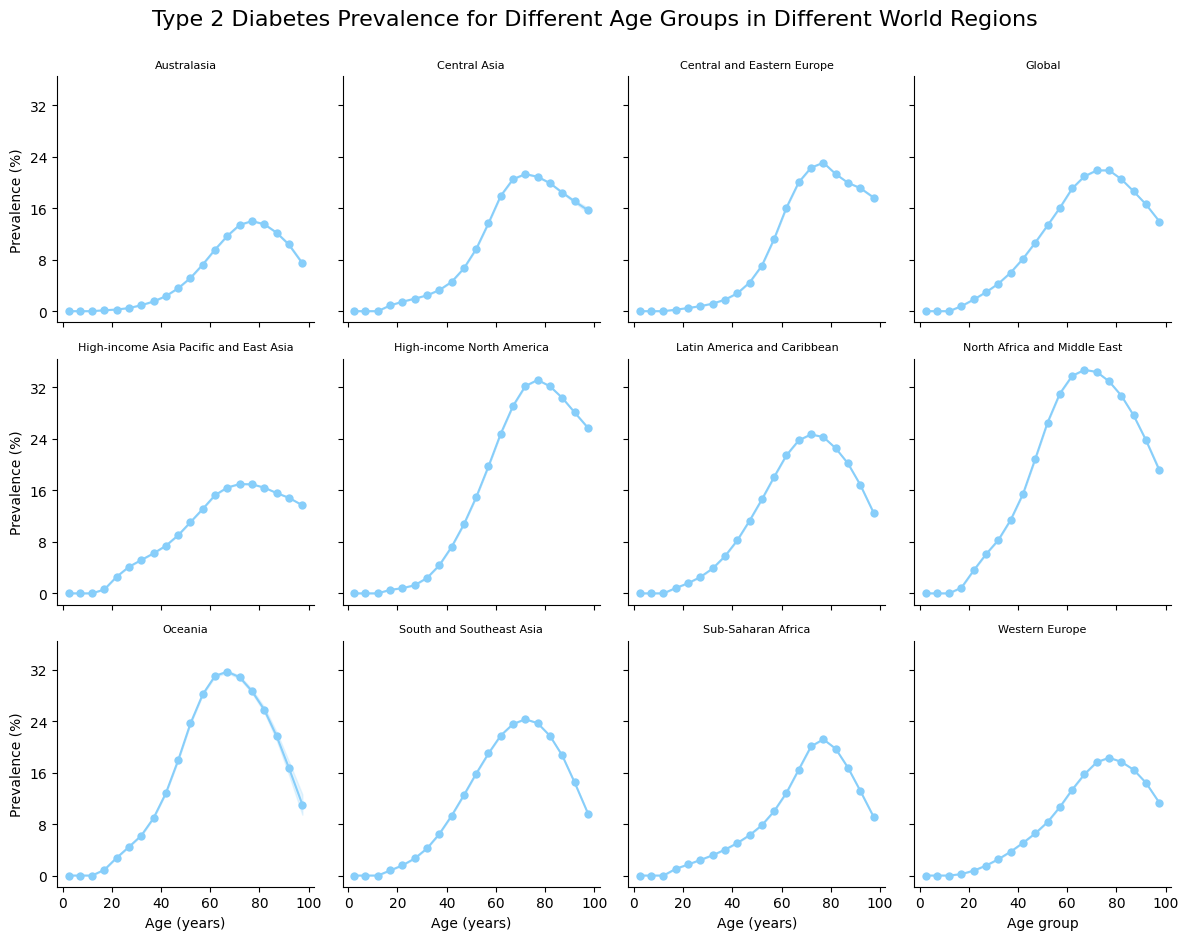

In [25]:
regions = df_region_age['region'].unique()
n = len(regions)
nrows=3
ncols=4

label_xaxis = list(range((nrows * ncols - ncols), nrows * ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3), sharex=True, sharey=True)

axes = axes.flatten()

count = 0

for ax, region in zip(axes, regions):

    region_df = df_region_age[df_region_age['region'] == region]
    
    ax.plot(region_df['age_mid'], region_df['val_T2D']["Percent"], label='Mean', marker='o', markeredgewidth=0, color="lightskyblue")
    ax.fill_between(
        region_df['age_mid'],
        region_df['lower']["Percent"],
        region_df['upper']["Percent"],
        color='lightskyblue', alpha=0.2
    )


    col = count % ncols
    if col == 0:
        ax.set_ylabel("Prevalence (%)")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)


    if count in label_xaxis:
        ax.set_xlabel("Age (years)")
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelleft=False)
    count += 1
    

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.set_title(region, fontsize=8)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plt.xlabel("Age group")
plt.tight_layout()
fig.suptitle(
    "Type 2 Diabetes Prevalence for Different Age Groups in Different World Regions",
    y=1.04,
    fontsize=16)
plt.show()

### Age-standardised

https://towardsdatascience.com/a-beginners-guide-to-create-a-cloropleth-map-in-python-using-geopandas-and-matplotlib-9cc4175ab630/
https://r2.datahub.io/clvyjaryy0000la0cxieg4o8o/main/raw/data/countries.geojson

In [26]:
url = "https://r2.datahub.io/clvyjaryy0000la0cxieg4o8o/main/raw/data/countries.geojson"
df_map = gpd.read_file(url)
df_map = df_map[df_map["name"] != "Antarctica"]
# Check the GeoDataframe
df_map.head(2)

,name,ISO3166-1-Alpha-3,ISO3166-1-Alpha-2,geometry
0,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4..."
1,Malaysia,MYS,MY,"MULTIPOLYGON (((117.70361 4.16342, 117.69711 4..."


<Axes: >

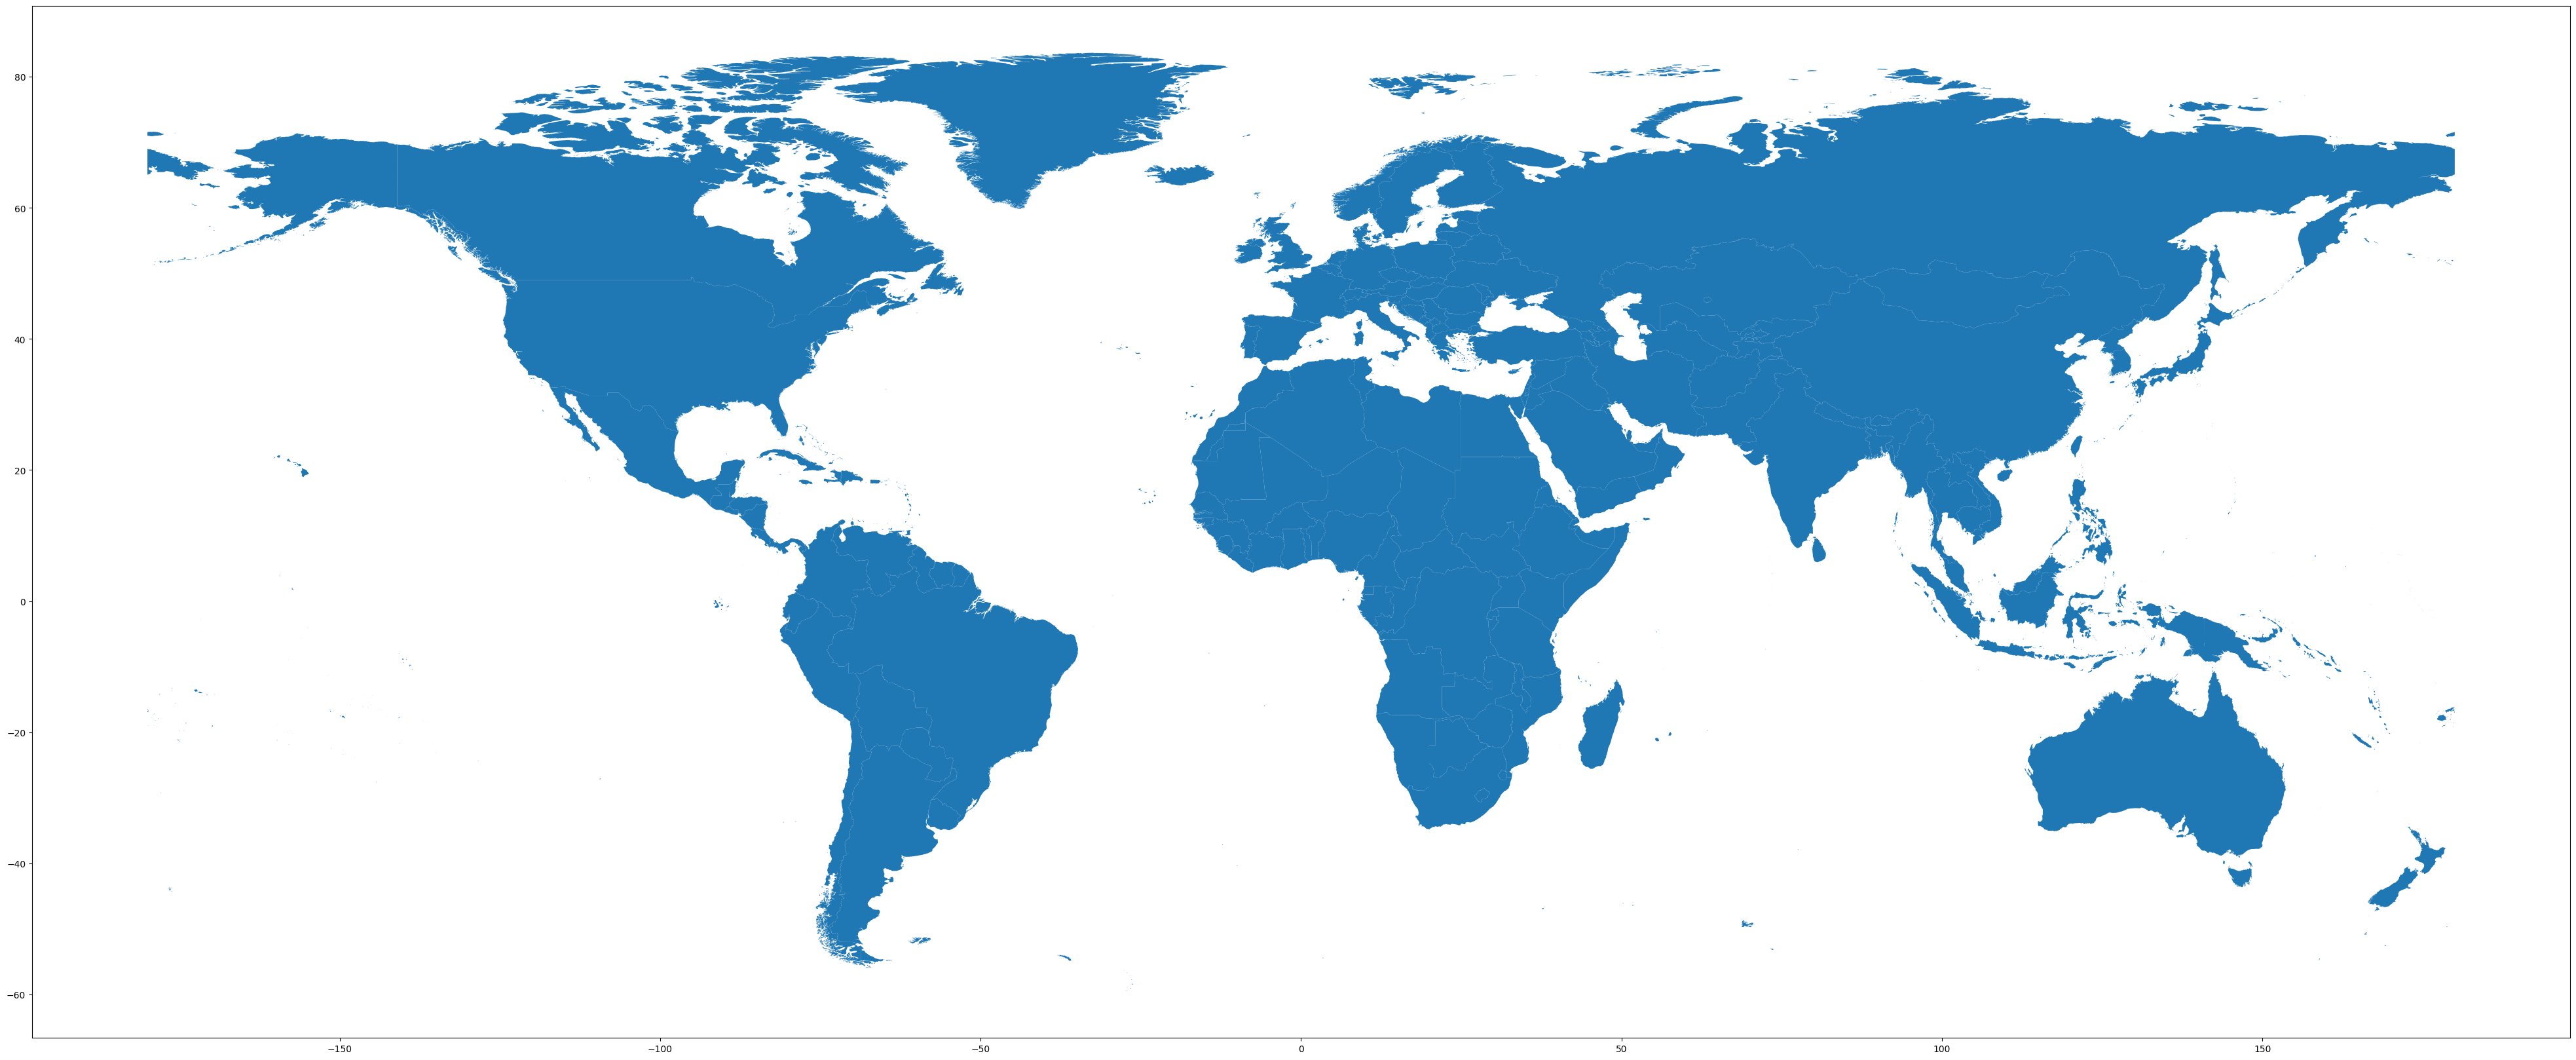

In [27]:
plt.rcParams['figure.figsize'] = [50, 70] #height, width
df_map.plot()

In [28]:
df_both_2023 = df.query("sex_name == 'Both' and year == 2023 and metric_name == 'Percent'")

In [29]:
absent = []
for country in df_map.name:
    if country not in df_both_2023.location_name.unique():
        absent.append(country)
df_absent = pd.DataFrame(absent)
df_absent

,0
0,Bolivia
1,Dhekelia Sovereign Base Area
2,Syria
3,Somaliland
4,South Korea
...,...
69,Macao S.A.R
70,Ashmore and Cartier Islands
71,Bajo Nuevo Bank (Petrel Is.)
72,Serranilla Bank


I manually curated the absent_df.csv 

In [30]:
country_map = {
    "Bolivia": "Bolivia (Plurinational State of)",
    "Dhekelia Sovereign Base Area": "Dhekelia Sovereign Base Area",
    "Syria": "Syrian Arab Republic",
    "Somaliland": "Somalia",
    "South Korea": "Republic of Korea",
    "North Korea": "Democratic People's Republic of Korea",
    "Western Sahara": "Western Sahara",
    "Republic of the Congo": "Democratic Republic of the Congo",
    "Saint Martin": "Saint Martin",
    "Sint Maarten": "Sint Maarten",
    "Russia": "Russian Federation",
    "Vietnam": "Viet Nam",
    "Kosovo": "Kosovo",
    "Turkey": "Türkiye",
    "Laos": "Lao P`eople's Democratic Republic",
    "Iran": "Iran (Islamic Republic of)",
    "Liechtenstein": "Liechtenstein",
    "Ivory Coast": "Côte d'Ivoire",
    "Republic of Serbia": "Serbia",
    "East Timor": "Timor-Leste",
    "Brunei": "Brunei Darussalam",
    "eSwatini": "Eswatini",
    "US Naval Base Guantanamo Bay": "US Naval Base Guantanamo Bay",
    "Brazilian Island": "Brazilian Island",
    "Moldova": "Republic of Moldova",
    "Gibraltar": "Gibraltar",
    "Venezuela": "Venezuela (Bolivarian Republic of)",
    "Hong Kong S.A.R.": "Hong Kong S.A.R.",
    "Vatican": "Vatican City",
    "Northern Cyprus": "Northern Cyprus",
    "Cyprus No Mans Area": "Cyprus No Mans Area",
    "Siachen Glacier": "Siachen Glacier",
    "Baykonur Cosmodrome": "Baykonur Cosmodrome",
    "Akrotiri Sovereign Base Area": "Akrotiri Sovereign Base Area",
    "Southern Patagonian Ice Field": "Southern Patagonian Ice Field",
    "Bir Tawil": "Bir Tawil",
    "New Caledonia": "New Caledonia",
    "Curaçao": "Curaçao",
    "Aruba": "Aruba",
    "The Bahamas": "Bahamas",
    "Turks and Caicos Islands": "Turks and Caicos Islands",
    "Saint Pierre and Miquelon": "Saint Pierre and Miquelon",
    "Pitcairn Islands": "Pitcairn Islands",
    "French Polynesia": "French Polynesia",
    "French Southern and Antarctic Lands": "French Southern and Antarctic Lands",
    "United States Minor Outlying Islands": "United States Minor Outlying Islands",
    "Montserrat": "Montserrat",
    "Saint Barthelemy": "Saint Barthelemy",
    "Anguilla": "Anguilla",
    "British Virgin Islands": "British Virgin Islands",
    "Cayman Islands": "Cayman Islands",
    "Heard Island and McDonald Islands": "Heard Island and McDonald Islands",
    "Saint Helena": "Saint Helena",
    "São Tomé and Principe": "Sao Tome and Principe",
    "Jersey": "Jersey",
    "Guernsey": "Guernsey",
    "Isle of Man": "Isle of Man",
    "Aland": "Aland",
    "Faroe Islands": "Faroe Islands",
    "Indian Ocean Territories": "Indian Ocean Territories",
    "British Indian Ocean Territory": "British Indian Ocean Territory",
    "Norfolk Island": "Norfolk Island",
    "Wallis and Futuna": "Wallis and Futuna",
    "Federated States of Micronesia": "Micronesia (Federated States of)",
    "South Georgia and the Islands": "South Georgia and the Islands",
    "Falkland Islands": "Falkland Islands",
    "Coral Sea Islands": "Coral Sea Islands",
    "Spratly Islands": "Spratly Islands",
    "Clipperton Island": "Clipperton Island",
    "Macao S.A.R": "Macao S.A.R",
    "Ashmore and Cartier Islands": "Ashmore and Cartier Islands",
    "Bajo Nuevo Bank (Petrel Is.)": "Bajo Nuevo Bank (Petrel Is.)",
    "Serranilla Bank": "Serranilla Bank",
    "Scarborough Reef": "Scarborough Reef"}

In [31]:
df_map["country_name_GBD"] = [
    acountry if acountry in df_both_2023.location_name.unique()
    else country_map[acountry]
    for acountry in df_map.name
]

In [32]:
merged = df_map.merge(df_both_2023, left_on='country_name_GBD', right_on='location_name', how='inner')


In [33]:
merged.head()

,name,ISO3166-1-Alpha-3,ISO3166-1-Alpha-2,geometry,country_name_GBD,measure_id,measure_name,location_id,location_name,sex_id,...,cause_name,metric_id,metric_name,year,val_T2D,upper,lower,val_population,val,region
0,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4...",Indonesia,5,Prevalence,11,Indonesia,3,...,Diabetes mellitus type 2,2,Percent,2023,NaN,5.592085,4.481300,NaN,5.019054,South and Southeast Asia
1,Malaysia,MYS,MY,"MULTIPOLYGON (((117.70361 4.16342, 117.69711 4...",Malaysia,5,Prevalence,13,Malaysia,3,...,Diabetes mellitus type 2,2,Percent,2023,NaN,8.553005,7.148465,NaN,7.806388,South and Southeast Asia
2,Chile,CHL,CL,"MULTIPOLYGON (((-69.51009 -17.50659, -69.50611...",Chile,5,Prevalence,98,Chile,3,...,Diabetes mellitus type 2,2,Percent,2023,NaN,2.790094,2.331628,NaN,2.547230,Latin America and Caribbean
3,Bolivia,BOL,BO,"POLYGON ((-69.51009 -17.50659, -69.51009 -17.5...",Bolivia (Plurinational State of),5,Prevalence,121,Bolivia (Plurinational State of),3,...,Diabetes mellitus type 2,2,Percent,2023,NaN,6.110296,5.029355,NaN,5.492040,Latin America and Caribbean
4,Peru,PER,PE,"MULTIPOLYGON (((-69.51009 -17.50659, -69.63832...",Peru,5,Prevalence,123,Peru,3,...,Diabetes mellitus type 2,2,Percent,2023,NaN,3.793399,3.198266,NaN,3.477896,Latin America and Caribbean


https://towardsdatascience.com/a-beginners-guide-to-create-a-cloropleth-map-in-python-using-geopandas-and-matplotlib-9cc4175ab630/
https://r2.datahub.io/clvyjaryy0000la0cxieg4o8o/main/raw/data/countries.geojson

In [34]:
data = merged.groupby(["country_name_GBD", "geometry", "region"]).mean("val").reset_index()

In [35]:
data = gpd.GeoDataFrame(data)
data.head()

,country_name_GBD,geometry,region,measure_id,location_id,sex_id,age_id,cause_id,metric_id,year,val_T2D,upper,lower,val_population,val
0,Afghanistan,"POLYGON ((74.54235 37.02167, 74.54742 37.01568...",North Africa and Middle East,5.0,160.0,3.0,27.0,976.0,2.0,2023.0,NaN,11.309915,9.487393,NaN,10.397503
1,Albania,"POLYGON ((20.56715 41.87318, 20.54172 41.86158...",Central and Eastern Europe,5.0,43.0,3.0,27.0,976.0,2.0,2023.0,NaN,3.440942,2.782335,NaN,3.065598
2,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",North Africa and Middle East,5.0,139.0,3.0,27.0,976.0,2.0,2023.0,NaN,12.339102,10.439089,NaN,11.354909
3,American Samoa,"MULTIPOLYGON (((-170.59101 -14.26482, -170.576...",Oceania,5.0,298.0,3.0,27.0,976.0,2.0,2023.0,NaN,18.312239,15.669434,NaN,16.936764
4,Andorra,"POLYGON ((1.70701 42.50278, 1.6975 42.49446, 1...",Western Europe,5.0,74.0,3.0,27.0,976.0,2.0,2023.0,NaN,3.627630,2.877364,NaN,3.216826


In [36]:
data.sort_values("val", ascending=False).head(5)

,country_name_GBD,geometry,region,measure_id,location_id,sex_id,age_id,cause_id,metric_id,year,val_T2D,upper,lower,val_population,val
157,Saudi Arabia,"MULTIPOLYGON (((50.80787 24.74665, 50.88101 24...",North Africa and Middle East,5.0,152.0,3.0,27.0,976.0,2.0,2023.0,NaN,25.674749,21.820285,NaN,23.725007
114,Micronesia (Federated States of),"MULTIPOLYGON (((163.02605 5.34089, 163.03045 5...",Oceania,5.0,25.0,3.0,27.0,976.0,2.0,2023.0,NaN,20.962620,18.711562,NaN,19.805676
95,Kuwait,"MULTIPOLYGON (((47.94801 29.99404, 47.95509 29...",North Africa and Middle East,5.0,145.0,3.0,27.0,976.0,2.0,2023.0,NaN,20.776739,17.653913,NaN,19.169400
13,Bahrain,"MULTIPOLYGON (((50.55161 26.19424, 50.59474 26...",North Africa and Middle East,5.0,140.0,3.0,27.0,976.0,2.0,2023.0,NaN,20.294040,17.374104,NaN,18.915473
110,Marshall Islands,"MULTIPOLYGON (((168.10108 5.59931, 168.10133 5...",Oceania,5.0,24.0,3.0,27.0,976.0,2.0,2023.0,NaN,19.455717,16.451292,NaN,17.986088


Add the plot within a plot
https://python-graph-gallery.com/how-to-add-plot-inside-plot/#:~:text=In%20practice%2C%20we%20add%20an,size%20of%20the%20smaller%20plot.

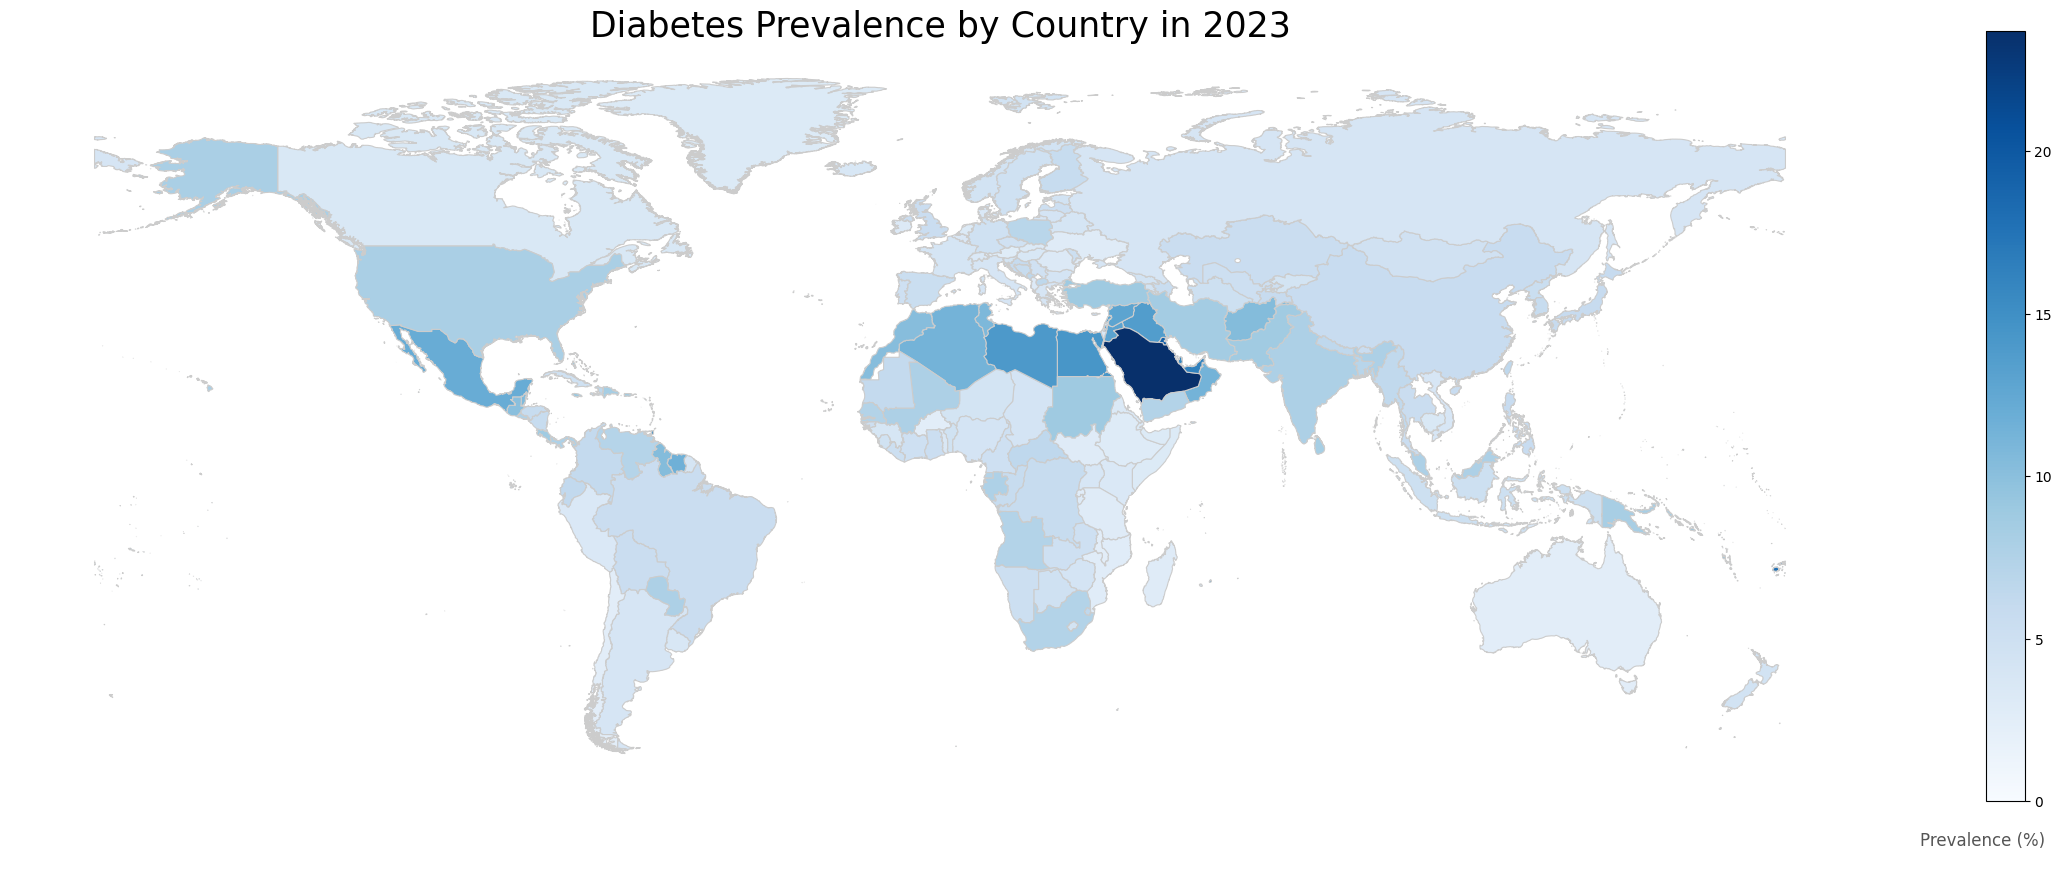

In [37]:
variable = 'val'
vmin, vmax = 0, round(data["val"].max(), 1)
fig, ax = plt.subplots(1, figsize=(30, 10))
ax.axis('off')
ax.set_title('Diabetes Prevalence by Country in 2023', fontdict={'fontsize': '25', 'fontweight' : '3'})
ax.annotate('Prevalence (%)', xy=(0.64, .04), xycoords='figure fraction', fontsize=12, color='#555555')

data.plot(column=variable, cmap='Blues', linewidth=0.8, ax=ax, edgecolor='0.8', 
            vmin=vmin, vmax=vmax)

sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, ax=ax)

# # create inset plot
# sub_ax = inset_axes(
#     parent_axes=ax,
#     width="35%",
#     height="45%",
#     loc="lower left",
#     borderpad=1  # padding between parent and inset axes
# )
# carribean_df = data[data["region"] == "Caribbean"]
# carribean_df.plot(column=variable, cmap='Blues', linewidth=0.8, ax=sub_ax, edgecolor='0.8', 
#             vmin=vmin, vmax=vmax)
# sub_ax.set_xticks([])
# sub_ax.set_yticks([])
# sub_ax.set_title('Diabetes Prevalence in Caribbean', fontdict={'fontsize': '12', 'fontweight' : '3'})

plt.show()

### Scatter plot

In [41]:
df_gender = df.query("sex_name in ['Male', 'Female'] and metric_name == 'Percent'")
df_gender

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val_T2D,upper,lower,val_population,val,region
0,5,Prevalence,38,Mongolia,1,Male,27,NaN,976,Diabetes mellitus type 2,2,Percent,1990,NaN,3.922373,3.105542,NaN,3.465991,Central Asia
1,5,Prevalence,38,Mongolia,2,Female,27,NaN,976,Diabetes mellitus type 2,2,Percent,1990,NaN,3.111988,2.527769,NaN,2.793835,Central Asia
3,5,Prevalence,61,Republic of Moldova,1,Male,27,NaN,976,Diabetes mellitus type 2,2,Percent,1990,NaN,3.205664,2.444204,NaN,2.818745,Central and Eastern Europe
4,5,Prevalence,61,Republic of Moldova,2,Female,27,NaN,976,Diabetes mellitus type 2,2,Percent,1990,NaN,2.811075,2.223818,NaN,2.514172,Central and Eastern Europe
6,5,Prevalence,49,North Macedonia,1,Male,27,NaN,976,Diabetes mellitus type 2,2,Percent,1990,NaN,4.357049,3.391534,NaN,3.843209,Central and Eastern Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20902,5,Prevalence,201,Burkina Faso,2,Female,27,NaN,976,Diabetes mellitus type 2,2,Percent,2023,NaN,2.604735,2.158040,NaN,2.378095,Sub-Saharan Africa
20904,5,Prevalence,380,Palau,1,Male,27,NaN,976,Diabetes mellitus type 2,2,Percent,2023,NaN,15.718415,13.306834,NaN,14.569973,Oceania
20905,5,Prevalence,380,Palau,2,Female,27,NaN,976,Diabetes mellitus type 2,2,Percent,2023,NaN,11.607371,9.801462,NaN,10.666698,Oceania
20907,5,Prevalence,416,Tuvalu,1,Male,27,NaN,976,Diabetes mellitus type 2,2,Percent,2023,NaN,12.685207,10.635798,NaN,11.640243,Oceania


In [43]:
df_pivot = (
    df_gender
    .pivot(
        index=["location_name", "year", "region"],
        columns="sex_name",
        values="val"
    )
    .reset_index()
)
df_pivot = df_pivot[df_pivot["year"] == 2023]

In [44]:
df_pivot

sex_name,location_name,year,region,Female,Male
33,Afghanistan,2023,North Africa and Middle East,9.856004,10.927273
67,Albania,2023,Central and Eastern Europe,2.605422,3.577978
101,Algeria,2023,North Africa and Middle East,11.281963,11.429343
135,American Samoa,2023,Oceania,16.189907,17.672080
169,Andorra,2023,Western Europe,2.549203,3.863996
...,...,...,...,...,...
6833,Venezuela (Bolivarian Republic of),2023,Latin America and Caribbean,6.433621,7.934686
6867,Viet Nam,2023,South and Southeast Asia,3.873272,3.741550
6901,Yemen,2023,North Africa and Middle East,7.305204,7.378305
6935,Zambia,2023,Sub-Saharan Africa,4.574364,5.371724


In [45]:
# Here is the list of colors https://en.wikipedia.org/wiki/List_of_colors:_A%E2%80%93F
colors_11 = [
    "#1f77b4",  # blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#e377c2",  # pink
    "#000000",  # black
    "#17becf",  # cyan
    "#FF00FF",  # fuchsia
    "#80FF00",  # chartreuse (web)
    "#00CC99",  # caribbean green
    "#964B00",  # brown
]

Text(0.5, 1.0, 'Diabetes Prevalence Between Age-standardised Men and Women')

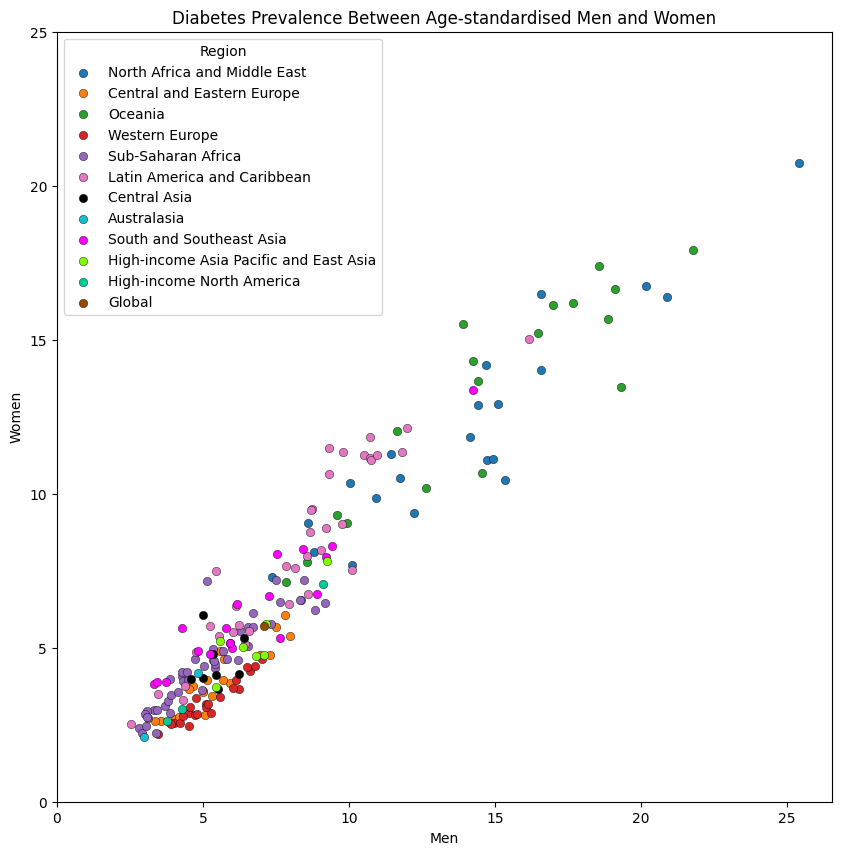

In [46]:
fig, ax = plt.subplots(figsize=(10, 10))



x = df_pivot["Male"]
y = df_pivot["Female"]
regions = df_pivot["region"].astype("category")
colors = regions.cat.codes

regions_unique = df_pivot["region"].unique()

for i, region in enumerate(regions_unique):
    df_temp = df_pivot[df_pivot["region"] == region]
    x = df_temp["Male"]
    y = df_temp["Female"]
    ax.scatter(
        x,
        y,
        alpha=1,
        edgecolors="black",
        linewidths=0.3,
        label=region,
        c=colors_11[i]
    )
ax.legend(title="Region")
plt.xlabel("Men")
plt.ylabel("Women")
plt.xticks([0, 5, 10, 15, 20, 25])
plt.yticks([0, 5, 10, 15, 20, 25])
plt.title("Diabetes Prevalence Between Age-standardised Men and Women")

## Plot 4

In [47]:
from matplotlib.collections import LineCollection

In [48]:
df_agestand = df[df["metric_name"] == "Percent"]

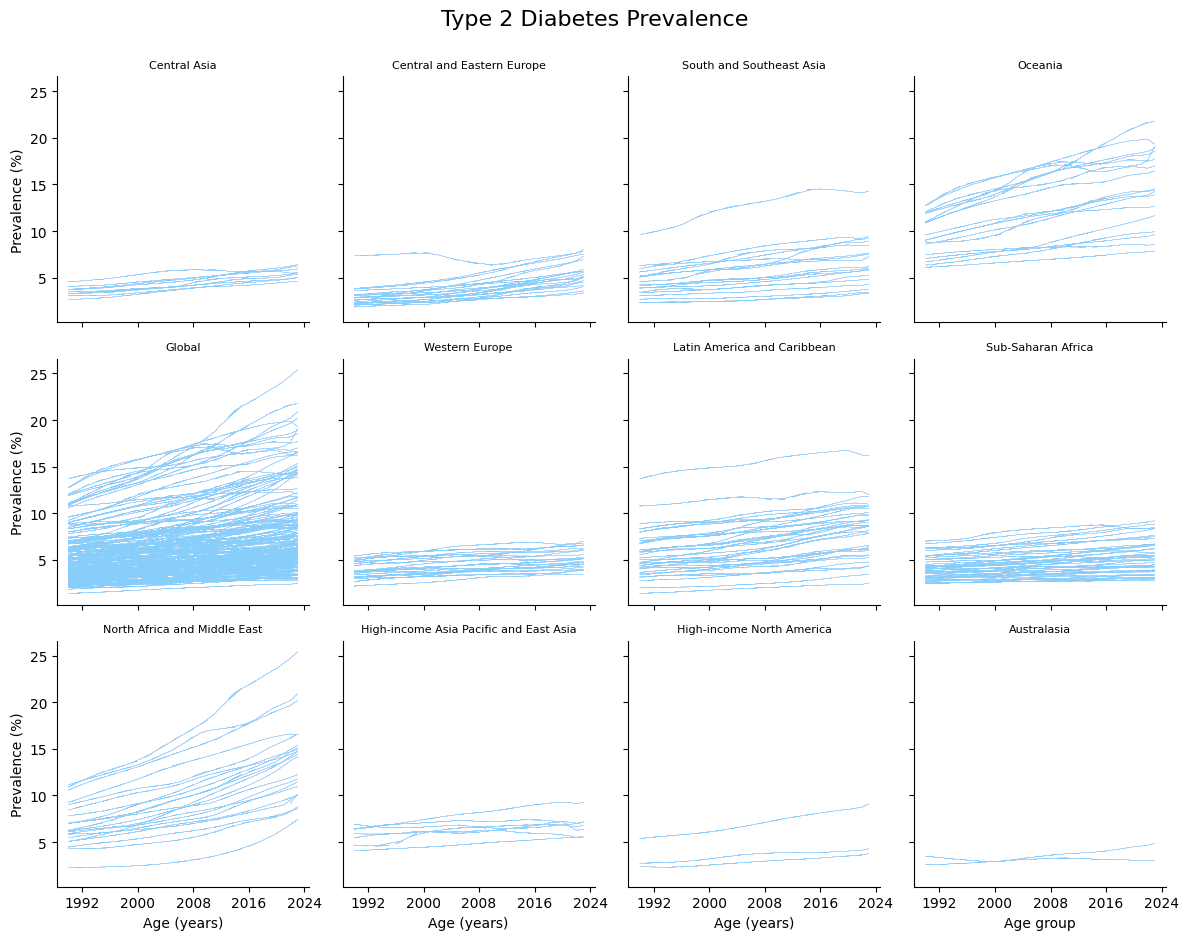

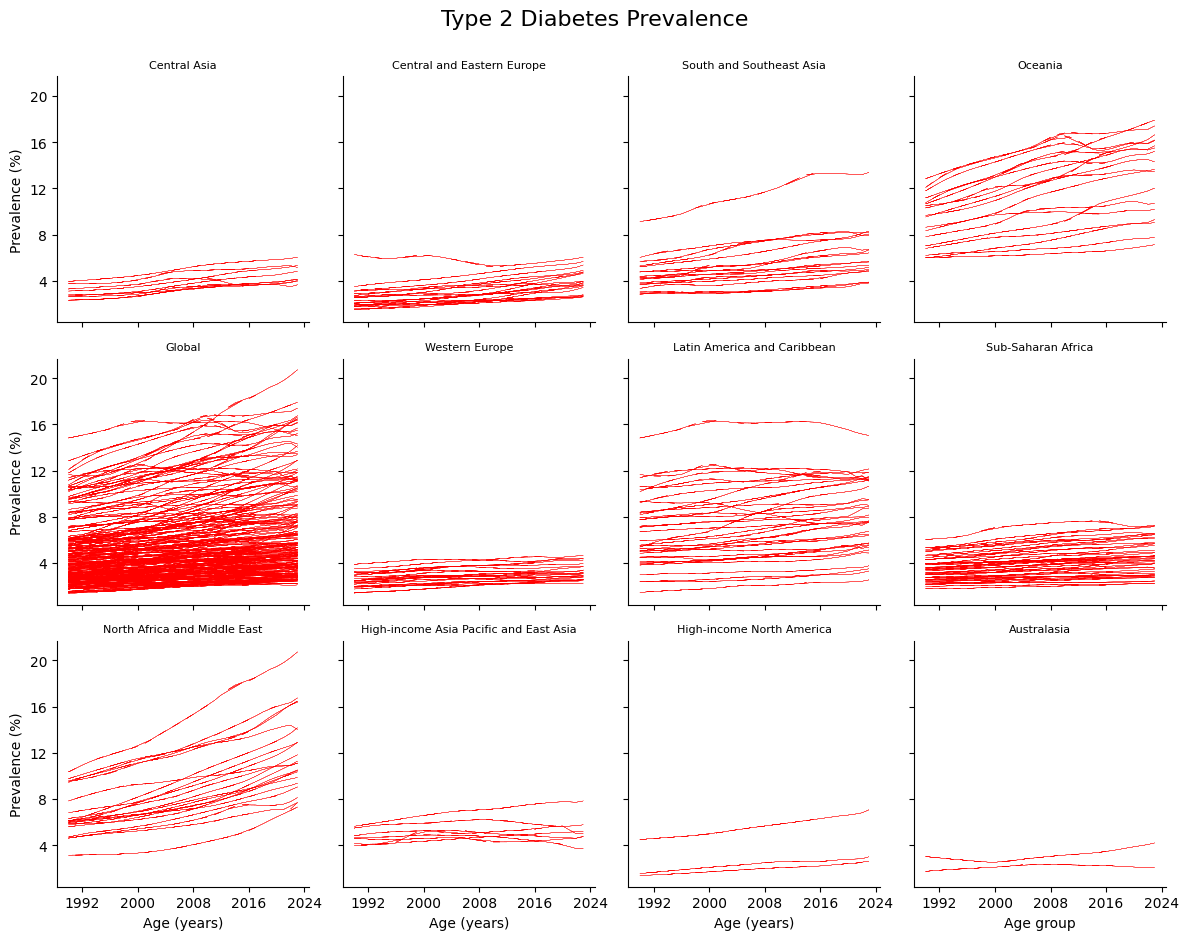

In [49]:
for gender in ["Male", "Female"]:

    color = {
        "Male": "lightskyblue",
        "Female": "red"
    }
    color = color[gender]


    df_agestand_gender = df_agestand[df_agestand["sex_name"] == gender]
    regions = df_agestand_gender['region'].unique()
    n = len(regions)
    nrows=3
    ncols=4

    label_xaxis = list(range((nrows * ncols - ncols), nrows * ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*3, nrows*3), sharex=True, sharey=True)

    axes = axes.flatten()

    count = 0

    for ax, region in zip(axes, regions):

        if region == "Global":
            region_df = df_agestand_gender
        else:
            region_df = df_agestand_gender[df_agestand_gender['region'] == region]
        
        for location in region_df["location_name"]:

            df_location = region_df[region_df["location_name"] == location]
            ax.plot(df_location['year'], df_location["val"], linewidth=0.1, color=color, alpha=0.2)
            

        col = count % ncols
        if col == 0:
            ax.set_ylabel("Prevalence (%)")
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelleft=False)


        if count in label_xaxis:
            ax.set_xlabel("Age (years)")
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelleft=False)
        count += 1
        

        ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.set_title(region, fontsize=8)
        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


    plt.xlabel("Age group")
    plt.tight_layout()
    fig.suptitle(
        "Type 2 Diabetes Prevalence",
        y=1.04,
        fontsize=16)
    plt.show()